In [1]:
# ==========================================================
# VERIFICACIÓN DEL ENTORNO
# ==========================================================

import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ==========================================================
# INSTALACIÓN DE LIBRERÍAS
# ==========================================================

!pip install -q --upgrade kaggle
!pip install -q seaborn scikit-learn pandas gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 13.0 MB/s eta 0:00:00


In [4]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import os
import time
import random
import shutil
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [5]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_686c3a7588527504764ccc6fd7681dee"

In [6]:
# ==========================================================
# DESCARGA DEL DATASET
# ==========================================================

!kaggle datasets download \
-d programmer3/concrete-structural-defect-imaging-dataset

!unzip -q concrete-structural-defect-imaging-dataset.zip

print("Dataset descargado y descomprimido.")

Dataset URL: https://www.kaggle.com/datasets/programmer3/concrete-structural-defect-imaging-dataset
License(s): CC0-1.0
100% 80.6M/80.6M [00:00<00:00, 247MB/s]

Dataset descargado y descomprimido.


In [7]:
# ==========================================================
# PARÁMETROS GENERALES
# ==========================================================

DATASET_PATH = Path("/content/Building_Dataset")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 7

MAX_EPOCHS_FASE_1 = 15
MAX_EPOCHS_FINE = 5

tf.keras.utils.set_random_seed(SEED)

print("Ruta:", DATASET_PATH)

Ruta: /content/Building_Dataset


In [8]:
# ==========================================================
# SELECCIÓN DE LAS 7 CLASES
# ==========================================================

CLASS_NAMES = [
    "algae",
    "major_crack",
    "minor_crack",
    "normal",
    "peeling",
    "spalling",
    "stain"
]

print("Clases utilizadas:", CLASS_NAMES)
print("Número de clases:", len(CLASS_NAMES))

Clases utilizadas: ['algae', 'major_crack', 'minor_crack', 'normal', 'peeling', 'spalling', 'stain']
Número de clases: 7


In [9]:
# ==========================================================
# REGISTRO DE IMÁGENES
# ==========================================================

FORMATOS_VALIDOS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

registros = []

for clase in CLASS_NAMES:
    carpeta_clase = DATASET_PATH / clase

    if not carpeta_clase.exists():
        raise FileNotFoundError(
            f"No se encontró la carpeta de la clase: {clase}"
        )

    for archivo in carpeta_clase.iterdir():
        if archivo.is_file() and archivo.suffix.lower() in FORMATOS_VALIDOS:
            registros.append({
                "filepath": str(archivo),
                "label": clase
            })

df = pd.DataFrame(registros)

print("Total de imágenes:", len(df))
print("\nDistribución:")
print(df["label"].value_counts())

Total de imágenes: 2980

Distribución:
label
algae          520
major_crack    480
normal         450
peeling        420
minor_crack    380
stain          380
spalling       350
Name: count, dtype: int64


In [10]:
# ==========================================================
# VERIFICACIÓN DE IMÁGENES
# ==========================================================

imagenes_validas = []
imagenes_danadas = []

for ruta in df["filepath"]:
    try:
        with Image.open(ruta) as img:
            img.verify()
        imagenes_validas.append(ruta)
    except Exception:
        imagenes_danadas.append(ruta)

df = df[df["filepath"].isin(imagenes_validas)].reset_index(drop=True)

print("Imágenes válidas:", len(df))
print("Imágenes dañadas:", len(imagenes_danadas))

if imagenes_danadas:
    print("\nArchivos dañados:")
    for ruta in imagenes_danadas:
        print(ruta)

Imágenes válidas: 2980
Imágenes dañadas: 0


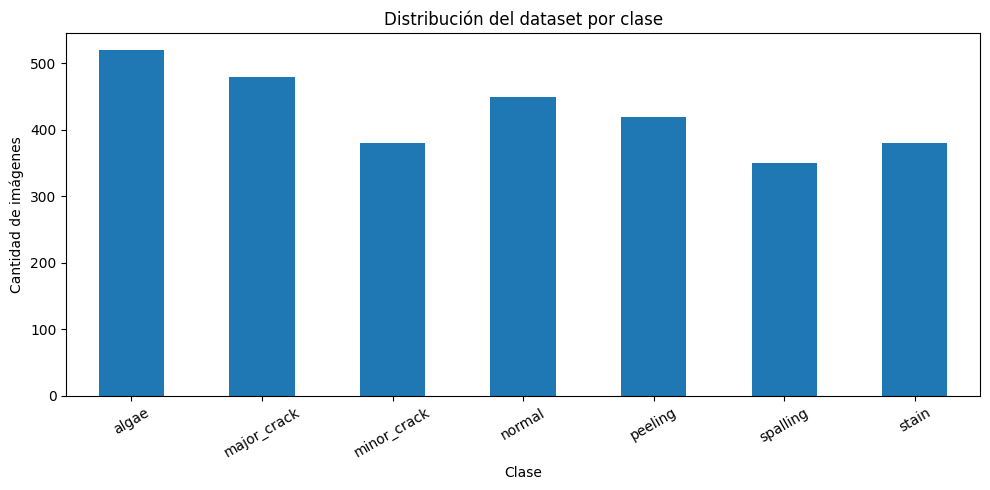

label
algae          520
major_crack    480
minor_crack    380
normal         450
peeling        420
spalling       350
stain          380
Name: count, dtype: int64


In [11]:
# ==========================================================
# DISTRIBUCIÓN DE LAS SIETE CLASES
# ==========================================================

conteo_clases = (
    df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

plt.figure(figsize=(10, 5))
conteo_clases.plot(kind="bar")

plt.title("Distribución del dataset por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "01_distribucion_7_clases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(conteo_clases)

In [12]:
# ==========================================================
# DIVISIÓN ESTRATIFICADA 70/15/15
# ==========================================================

train_df, temporal_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporal_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporal_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Entrenamiento:", len(train_df))
print("Validación:", len(validation_df))
print("Prueba:", len(test_df))

print("\nPorcentajes reales:")
print(f"Train: {len(train_df) / len(df) * 100:.2f}%")
print(f"Validation: {len(validation_df) / len(df) * 100:.2f}%")
print(f"Test: {len(test_df) / len(df) * 100:.2f}%")

Entrenamiento: 2086
Validación: 447
Prueba: 447

Porcentajes reales:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


In [13]:
# ==========================================================
# CONTROL DE FUGA DE DATOS
# ==========================================================

train_paths = set(train_df["filepath"])
validation_paths = set(validation_df["filepath"])
test_paths = set(test_df["filepath"])

assert train_paths.isdisjoint(validation_paths)
assert train_paths.isdisjoint(test_paths)
assert validation_paths.isdisjoint(test_paths)

print("No existen imágenes repetidas entre train, validation y test.")

No existen imágenes repetidas entre train, validation y test.


In [14]:
# ==========================================================
# DISTRIBUCIÓN POR CONJUNTO
# ==========================================================

distribucion = pd.DataFrame({
    "Entrenamiento": train_df["label"].value_counts(),
    "Validación": validation_df["label"].value_counts(),
    "Prueba": test_df["label"].value_counts()
}).reindex(CLASS_NAMES)

print(distribucion)

             Entrenamiento  Validación  Prueba
label                                         
algae                  364          78      78
major_crack            336          72      72
minor_crack            266          57      57
normal                 315          67      68
peeling                294          63      63
spalling               245          53      52
stain                  266          57      57


In [15]:
# ==========================================================
# CODIFICACIÓN DE ETIQUETAS
# ==========================================================

label_to_index = {
    clase: indice
    for indice, clase in enumerate(CLASS_NAMES)
}

index_to_label = {
    indice: clase
    for clase, indice in label_to_index.items()
}

train_df["label_id"] = train_df["label"].map(label_to_index)
validation_df["label_id"] = validation_df["label"].map(label_to_index)
test_df["label_id"] = test_df["label"].map(label_to_index)

print(label_to_index)

{'algae': 0, 'major_crack': 1, 'minor_crack': 2, 'normal': 3, 'peeling': 4, 'spalling': 5, 'stain': 6}


In [16]:
# ==========================================================
# FUNCIÓN PARA CARGAR IMÁGENES
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

def cargar_imagen(ruta, etiqueta):
    contenido = tf.io.read_file(ruta)

    imagen = tf.io.decode_image(
        contenido,
        channels=3,
        expand_animations=False
    )

    imagen.set_shape([None, None, 3])

    imagen = tf.image.resize(
        imagen,
        IMG_SIZE
    )

    imagen = tf.cast(
        imagen,
        tf.float32
    )

    return imagen, etiqueta

In [17]:
# ==========================================================
# CONSTRUCCIÓN DE DATASETS TF.DATA
# ==========================================================

def crear_dataset(dataframe, entrenamiento=False):
    rutas = dataframe["filepath"].values
    etiquetas = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (rutas, etiquetas)
    )

    dataset = dataset.map(
        cargar_imagen,
        num_parallel_calls=AUTOTUNE
    )

    if entrenamiento:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [18]:
train_ds = crear_dataset(
    train_df,
    entrenamiento=True
)

validation_ds = crear_dataset(
    validation_df,
    entrenamiento=False
)

test_ds = crear_dataset(
    test_df,
    entrenamiento=False
)

print("Datasets creados correctamente.")

Datasets creados correctamente.


In [19]:
# ==========================================================
# VERIFICACIÓN DE DIMENSIONES
# ==========================================================

for imagenes, etiquetas in train_ds.take(1):
    print("Forma de las imágenes:", imagenes.shape)
    print("Forma de las etiquetas:", etiquetas.shape)
    print("Rango mínimo:", tf.reduce_min(imagenes).numpy())
    print("Rango máximo:", tf.reduce_max(imagenes).numpy())

Forma de las imágenes: (32, 224, 224, 3)
Forma de las etiquetas: (32,)
Rango mínimo: 0.0
Rango máximo: 255.0


In [20]:
# ==========================================================
# DATA AUGMENTATION
# ==========================================================

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

In [21]:
# ==========================================================
# PESOS DE CLASES
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label_id"].values
)

class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(pesos)
}

print("Pesos de las clases:\n")

for indice, peso in class_weights.items():
    print(
        f"{index_to_label[indice]:15} -> {peso:.4f}"
    )

Pesos de las clases:

algae           -> 0.8187
major_crack     -> 0.8869
minor_crack     -> 1.1203
normal          -> 0.9460
peeling         -> 1.0136
spalling        -> 1.2163
stain           -> 1.1203


In [22]:
# ==========================================================
# FUNCIÓN GENERAL PARA CREAR MODELOS
# ==========================================================

from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    MobileNetV2,
    EfficientNetB0
)

from tensorflow.keras.applications.vgg16 import (
    preprocess_input as preprocess_vgg16
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as preprocess_resnet50
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as preprocess_mobilenetv2
)

from tensorflow.keras.applications.efficientnet import (
    preprocess_input as preprocess_efficientnet
)


def crear_modelo(nombre_modelo):
    nombre_modelo = nombre_modelo.lower()

    configuraciones = {
        "vgg16": {
            "arquitectura": VGG16,
            "preprocesamiento": preprocess_vgg16
        },
        "resnet50": {
            "arquitectura": ResNet50,
            "preprocesamiento": preprocess_resnet50
        },
        "mobilenetv2": {
            "arquitectura": MobileNetV2,
            "preprocesamiento": preprocess_mobilenetv2
        },
        "efficientnetb0": {
            "arquitectura": EfficientNetB0,
            "preprocesamiento": preprocess_efficientnet
        }
    }

    if nombre_modelo not in configuraciones:
        raise ValueError(
            f"Modelo no válido: {nombre_modelo}"
        )

    configuracion = configuraciones[nombre_modelo]

    base_model = configuracion["arquitectura"](
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(
        shape=(224, 224, 3),
        name="imagen_entrada"
    )

    x = data_augmentation(inputs)

    x = layers.Lambda(
        configuracion["preprocesamiento"],
        name=f"preprocesamiento_{nombre_modelo}"
    )(x)

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout_1"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="dense_128"
    )(x)

    x = layers.Dropout(
        0.3,
        name="dropout_2"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="clasificacion"
    )(x)

    modelo = Model(
        inputs,
        outputs,
        name=f"modelo_{nombre_modelo}"
    )

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo, base_model

In [55]:
# ==========================================================
# RESUMEN DE LAS 4 ARQUITECTURAS CNN
# ==========================================================

for nombre, modelo in modelos_finales.items():

    print("\n")
    print("=" * 100)
    print(f"RESUMEN DEL MODELO: {nombre.upper()}")
    print("=" * 100)

    modelo.summary()

    print("\n")



RESUMEN DEL MODELO: VGG16


Model: "modelo_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocesamiento_vgg16 (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clasificacion (Dense)           │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,815 (56.76 MB)

 Trainable params: 7,244,551 (27.64 MB)

...

Model: "modelo_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocesamiento_efficientnetb0 │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clasificacion (Dense)           │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,306 (16.83 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
# ==========================================================
# COMPROBACIÓN DE ARQUITECTURAS
# ==========================================================

NOMBRES_MODELOS = [
    "vgg16",
    "resnet50",
    "mobilenetv2",
    "efficientnetb0"
]

for nombre in NOMBRES_MODELOS:
    print("\n" + "=" * 60)
    print("Construyendo:", nombre.upper())

    modelo_prueba, base_prueba = crear_modelo(nombre)

    print("Parámetros totales:", modelo_prueba.count_params())
    print("Capas de la base:", len(base_prueba.layers))

    del modelo_prueba
    del base_prueba

    tf.keras.backend.clear_session()
    gc.collect()


Construyendo: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros totales: 14879815
Capas de la base: 19

Construyendo: RESNET50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parámetros totales: 24146055
Capas de la base: 175

Construyendo: MOBILENETV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros totales: 2619719
Capas de la base: 154

Construyendo: EFFICIENTNETB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parámetros totales: 4411306
Capas de la base: 238


In [31]:
# ==========================================================
# FUNCIÓN DE ENTRENAMIENTO EN DOS FASES
# 15 épocas Transfer Learning + 5 épocas Fine-Tuning
# ==========================================================

def entrenar_cnn(nombre_modelo):
    print("\n" + "=" * 85)
    print(f"INICIANDO ENTRENAMIENTO: {nombre_modelo.upper()}")
    print("=" * 85)

    # Construir modelo
    modelo, base_model = crear_modelo(nombre_modelo)

    # Rutas para guardar los mejores modelos
    ruta_fase1 = f"mejor_{nombre_modelo}_fase1.keras"
    ruta_final = f"mejor_{nombre_modelo}_final.keras"

    # ------------------------------------------------------
    # FASE 1: TRANSFER LEARNING
    # ------------------------------------------------------

    print("\n" + "-" * 85)
    print(f"FASE 1 — TRANSFER LEARNING: {nombre_modelo.upper()}")
    print("Base convolucional congelada")
    print("Máximo: 15 épocas")
    print("-" * 85)

    callbacks_fase1 = [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            ruta_fase1,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    inicio_fase1 = time.time()

    history_fase1 = modelo.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=15,
        callbacks=callbacks_fase1,
        class_weight=class_weights,
        verbose=1
    )

    tiempo_fase1 = (time.time() - inicio_fase1) / 60

    # ------------------------------------------------------
    # FASE 2: FINE-TUNING
    # ------------------------------------------------------

    print("\n" + "-" * 85)
    print(f"FASE 2 — FINE-TUNING: {nombre_modelo.upper()}")
    print("Se entrenará aproximadamente el último 20% de la base")
    print("Máximo: 5 épocas adicionales")
    print("-" * 85)

    base_model.trainable = True

    # Congelar el 80% inicial y liberar el 20% final
    punto_descongelamiento = int(len(base_model.layers) * 0.80)

    for capa in base_model.layers[:punto_descongelamiento]:
        capa.trainable = False

    for capa in base_model.layers[punto_descongelamiento:]:
        capa.trainable = True

    print("Capas totales de la base:", len(base_model.layers))
    print(
        "Capas liberadas para Fine-Tuning:",
        len(base_model.layers) - punto_descongelamiento
    )

    # Recompilar con learning rate más pequeño
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-5
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks_fase2 = [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            ruta_final,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    inicio_fase2 = time.time()

    history_fase2 = modelo.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=20,
        initial_epoch=15,
        callbacks=callbacks_fase2,
        class_weight=class_weights,
        verbose=1
    )

    tiempo_fase2 = (time.time() - inicio_fase2) / 60
    tiempo_total = tiempo_fase1 + tiempo_fase2

    mejor_val_fase1 = max(history_fase1.history["val_accuracy"])
    mejor_val_fase2 = max(history_fase2.history["val_accuracy"])

    print("\n" + "=" * 85)
    print(f"ENTRENAMIENTO FINALIZADO: {nombre_modelo.upper()}")
    print(f"Mejor validación Fase 1: {mejor_val_fase1:.4f}")
    print(f"Mejor validación Fase 2: {mejor_val_fase2:.4f}")
    print(f"Tiempo Fase 1: {tiempo_fase1:.2f} minutos")
    print(f"Tiempo Fine-Tuning: {tiempo_fase2:.2f} minutos")
    print(f"Tiempo total: {tiempo_total:.2f} minutos")
    print(f"Modelo final guardado: {ruta_final}")
    print("=" * 85)

    return {
        "modelo": modelo,
        "base_model": base_model,
        "history_fase1": history_fase1,
        "history_fase2": history_fase2,
        "tiempo_fase1": tiempo_fase1,
        "tiempo_fase2": tiempo_fase2,
        "tiempo_total": tiempo_total,
        "mejor_val_accuracy": max(
            mejor_val_fase1,
            mejor_val_fase2
        ),
        "ruta_modelo": ruta_final
    }

In [32]:
# ==========================================================
# MODELO 1 DE 4: VGG16
# ==========================================================

resultado_vgg16 = entrenar_cnn("vgg16")


INICIANDO ENTRENAMIENTO: VGG16

-------------------------------------------------------------------------------------
FASE 1 — TRANSFER LEARNING: VGG16
Base convolucional congelada
Máximo: 15 épocas
-------------------------------------------------------------------------------------
Epoch 1/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1613 - loss: 3.0437
Epoch 1: val_accuracy improved from None to 0.39374, saving model to mejor_vgg16_fase1.keras

Epoch 1: finished saving model to mejor_vgg16_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1798 - loss: 2.7421 - val_accuracy: 0.3937 - val_loss: 1.6762 - learning_rate: 1.0000e-04
Epoch 2/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2729 - loss: 2.1019
Epoch 2: val_accuracy improved from 0.39374 to 0.49888, saving model to mejor_vgg16_fase1.keras

Epoch 2: finished saving model to mejor_vgg16_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2848 - loss: 2.0593 - val_accuracy: 0.4

In [33]:
# ==========================================================
# MODELO 2 DE 4: RESNET50
# ==========================================================

resultado_resnet50 = entrenar_cnn("resnet50")


INICIANDO ENTRENAMIENTO: RESNET50

-------------------------------------------------------------------------------------
FASE 1 — TRANSFER LEARNING: RESNET50
Base convolucional congelada
Máximo: 15 épocas
-------------------------------------------------------------------------------------
Epoch 1/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2522 - loss: 2.0666
Epoch 1: val_accuracy improved from None to 0.71141, saving model to mejor_resnet50_fase1.keras

Epoch 1: finished saving model to mejor_resnet50_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.3346 - loss: 1.8413 - val_accuracy: 0.7114 - val_loss: 1.1663 - learning_rate: 1.0000e-04
Epoch 2/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5339 - loss: 1.3416
Epoch 2: val_accuracy improved from 0.71141 to 0.80761, saving model to mejor_resnet50_fase1.keras

Epoch 2: finished saving model to mejor_resnet50_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5614 - loss: 1.2582 

In [34]:
# ==========================================================
# MODELO 3 DE 4: MOBILENETV2
# ==========================================================

resultado_mobilenetv2 = entrenar_cnn("mobilenetv2")


INICIANDO ENTRENAMIENTO: MOBILENETV2

-------------------------------------------------------------------------------------
FASE 1 — TRANSFER LEARNING: MOBILENETV2
Base convolucional congelada
Máximo: 15 épocas
-------------------------------------------------------------------------------------
Epoch 1/15
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2145 - loss: 2.1774
Epoch 1: val_accuracy improved from None to 0.65548, saving model to mejor_mobilenetv2_fase1.keras

Epoch 1: finished saving model to mejor_mobilenetv2_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.2804 - loss: 1.9142 - val_accuracy: 0.6555 - val_loss: 1.2876 - learning_rate: 1.0000e-04
Epoch 2/15
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4608 - loss: 1.4581
Epoch 2: val_accuracy improved from 0.65548 to 0.76286, saving model to mejor_mobilenetv2_fase1.keras

Epoch 2: finished saving model to mejor_mobilenetv2_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.502

In [35]:
# ==========================================================
# MODELO 4 DE 4: EFFICIENTNETB0
# ==========================================================

resultado_efficientnetb0 = entrenar_cnn("efficientnetb0")


INICIANDO ENTRENAMIENTO: EFFICIENTNETB0

-------------------------------------------------------------------------------------
FASE 1 — TRANSFER LEARNING: EFFICIENTNETB0
Base convolucional congelada
Máximo: 15 épocas
-------------------------------------------------------------------------------------
Epoch 1/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2368 - loss: 1.8793
Epoch 1: val_accuracy improved from None to 0.68680, saving model to mejor_efficientnetb0_fase1.keras

Epoch 1: finished saving model to mejor_efficientnetb0_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.3015 - loss: 1.7909 - val_accuracy: 0.6868 - val_loss: 1.4327 - learning_rate: 1.0000e-04
Epoch 2/15
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4950 - loss: 1.4917
Epoch 2: val_accuracy improved from 0.68680 to 0.76063, saving model to mejor_efficientnetb0_fase1.keras

Epoch 2: finished saving model to mejor_efficientnetb0_fase1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/ste

In [37]:
# ==========================================================
# CARGAR EL MEJOR MODELO DE CADA ARQUITECTURA
# CORRECCIÓN PARA LAS CAPAS LAMBDA
# ==========================================================

import tensorflow as tf

from tensorflow.keras.applications.vgg16 import (
    preprocess_input as preprocess_vgg16
)
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as preprocess_resnet50
)
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as preprocess_mobilenetv2
)
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as preprocess_efficientnet
)


def cargar_modelo_seguro(archivo, funcion_preprocesamiento):
    """
    Carga un modelo indicando explícitamente la función
    preprocess_input utilizada en su capa Lambda.
    """

    modelo = tf.keras.models.load_model(
        archivo,
        custom_objects={
            "preprocess_input": funcion_preprocesamiento
        },
        compile=False,
        safe_mode=False
    )

    # Se recompila únicamente para poder usar model.evaluate().
    # Esto NO vuelve a entrenar el modelo.
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


modelos_finales = {}

print("Cargando VGG16...")
modelos_finales["VGG16"] = cargar_modelo_seguro(
    "mejor_vgg16_final.keras",
    preprocess_vgg16
)

print("Cargando ResNet50...")
modelos_finales["ResNet50"] = cargar_modelo_seguro(
    "mejor_resnet50_final.keras",
    preprocess_resnet50
)

# MobileNetV2 fue mejor en la Fase 1
print("Cargando MobileNetV2...")
modelos_finales["MobileNetV2"] = cargar_modelo_seguro(
    "mejor_mobilenetv2_fase1.keras",
    preprocess_mobilenetv2
)

# EfficientNetB0 fue mejor en la Fase 1
print("Cargando EfficientNetB0...")
modelos_finales["EfficientNetB0"] = cargar_modelo_seguro(
    "mejor_efficientnetb0_fase1.keras",
    preprocess_efficientnet
)

print("\nLos cuatro mejores modelos fueron cargados correctamente.")

Cargando VGG16...
Cargando ResNet50...
Cargando MobileNetV2...
Cargando EfficientNetB0...

Los cuatro mejores modelos fueron cargados correctamente.


In [39]:
# ==========================================================
# FUNCIÓN DE EVALUACIÓN FINAL
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluar_modelo(nombre_modelo, modelo):
    print("\n" + "=" * 85)
    print(f"EVALUACIÓN FINAL EN TEST: {nombre_modelo.upper()}")
    print("=" * 85)

    # Evaluación de pérdida y accuracy
    test_loss, test_accuracy = modelo.evaluate(
        test_ds,
        verbose=1
    )

    # Predicciones
    inicio_prediccion = time.time()

    probabilidades = modelo.predict(
        test_ds,
        verbose=1
    )

    tiempo_prediccion = time.time() - inicio_prediccion

    y_pred = np.argmax(
        probabilidades,
        axis=1
    )

    # Las etiquetas mantienen el mismo orden de test_ds
    y_true = test_df["label_id"].to_numpy()

    # Métricas globales multiclase
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    reporte = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )

    matriz = confusion_matrix(
        y_true,
        y_pred
    )

    print("\nRESULTADOS GLOBALES")
    print("-" * 45)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Precision:     {precision:.4f}")
    print(f"Recall:        {recall:.4f}")
    print(f"F1-Score:      {f1:.4f}")
    print(f"Tiempo de predicción: {tiempo_prediccion:.2f} segundos")

    print("\nCLASSIFICATION REPORT")
    print(reporte)

    return {
        "Modelo": nombre_modelo,
        "Test Accuracy": float(test_accuracy),
        "Test Loss": float(test_loss),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1-Score": float(f1),
        "Tiempo predicción (s)": float(tiempo_prediccion),
        "y_true": y_true,
        "y_pred": y_pred,
        "probabilidades": probabilidades,
        "matriz_confusion": matriz,
        "classification_report": reporte
    }

In [40]:
# ==========================================================
# EVALUACIÓN DE LOS CUATRO MODELOS
# ==========================================================

resultados_evaluacion = {}

for nombre, modelo in modelos_finales.items():
    resultados_evaluacion[nombre] = evaluar_modelo(
        nombre,
        modelo
    )

print("\n" + "=" * 85)
print("EVALUACIÓN DE LAS CUATRO CNN FINALIZADA")
print("=" * 85)


EVALUACIÓN FINAL EN TEST: VGG16
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8523 - loss: 0.4403
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

RESULTADOS GLOBALES
---------------------------------------------
Test Accuracy: 0.8523
Test Loss:     0.4403
Precision:     0.8580
Recall:        0.8523
F1-Score:      0.8511
Tiempo de predicción: 0.75 segundos

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       algae     0.8750    0.9872    0.9277        78
 major_crack     0.7590    0.8750    0.8129        72
 minor_crack     0.7500    0.6842    0.7156        57
      normal     0.9851    0.9706    0.9778        68
     peeling     0.7794    0.8413    0.8092        63
    spalling     0.9487    0.7115    0.8132        52
       stain     0.9200    0.8070    0.8598        57

    accuracy                         0.8523       447
   macro avg     0.8596    0.8395    0.8452       447
weighted avg     0.8580    0.8523    0.8511       447


EVALUACIÓN FINAL EN

In [41]:
# ==========================================================
# TABLA COMPARATIVA FINAL
# ==========================================================

tiempos_entrenamiento = {
    "VGG16": resultado_vgg16["tiempo_total"],
    "ResNet50": resultado_resnet50["tiempo_total"],
    "MobileNetV2": resultado_mobilenetv2["tiempo_total"],
    "EfficientNetB0": resultado_efficientnetb0["tiempo_total"]
}

filas_comparacion = []

for nombre, resultado in resultados_evaluacion.items():
    filas_comparacion.append({
        "Modelo": nombre,
        "Accuracy Test": resultado["Test Accuracy"],
        "Loss Test": resultado["Test Loss"],
        "Precision": resultado["Precision"],
        "Recall": resultado["Recall"],
        "F1-Score": resultado["F1-Score"],
        "Tiempo entrenamiento (min)": tiempos_entrenamiento[nombre],
        "Tiempo predicción (s)": resultado["Tiempo predicción (s)"]
    })

tabla_comparativa = pd.DataFrame(filas_comparacion)

tabla_comparativa = tabla_comparativa.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("TABLA COMPARATIVA FINAL\n")

display(
    tabla_comparativa.style.format({
        "Accuracy Test": "{:.4f}",
        "Loss Test": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Tiempo entrenamiento (min)": "{:.2f}",
        "Tiempo predicción (s)": "{:.2f}"
    })
)

TABLA COMPARATIVA FINAL



,Modelo,Accuracy Test,Loss Test,Precision,Recall,F1-Score,Tiempo entrenamiento (min),Tiempo predicción (s)
0,ResNet50,0.8635,0.3680,0.8692,0.8635,0.8641,1.63,3.82
1,EfficientNetB0,0.8523,0.4558,0.8635,0.8523,0.8536,1.50,4.37
2,MobileNetV2,0.8523,0.4573,0.8593,0.8523,0.8529,1.09,3.41
3,VGG16,0.8523,0.4403,0.8580,0.8523,0.8511,1.08,0.75


In [42]:
tabla_comparativa.to_csv(
    "tabla_comparativa_4_cnn.csv",
    index=False
)

print("Tabla guardada como tabla_comparativa_4_cnn.csv")

Tabla guardada como tabla_comparativa_4_cnn.csv


In [43]:
# ==========================================================
# ORGANIZAR HISTORIALES DE ENTRENAMIENTO
# ==========================================================

historias_modelos = {
    "VGG16": resultado_vgg16,
    "ResNet50": resultado_resnet50,
    "MobileNetV2": resultado_mobilenetv2,
    "EfficientNetB0": resultado_efficientnetb0
}


def unir_historiales(resultado):
    historia_fase1 = resultado["history_fase1"].history
    historia_fase2 = resultado["history_fase2"].history

    return {
        "accuracy": (
            historia_fase1["accuracy"]
            + historia_fase2["accuracy"]
        ),
        "val_accuracy": (
            historia_fase1["val_accuracy"]
            + historia_fase2["val_accuracy"]
        ),
        "loss": (
            historia_fase1["loss"]
            + historia_fase2["loss"]
        ),
        "val_loss": (
            historia_fase1["val_loss"]
            + historia_fase2["val_loss"]
        )
    }


historiales_completos = {
    nombre: unir_historiales(resultado)
    for nombre, resultado in historias_modelos.items()
}

print("Historiales organizados correctamente.")

Historiales organizados correctamente.


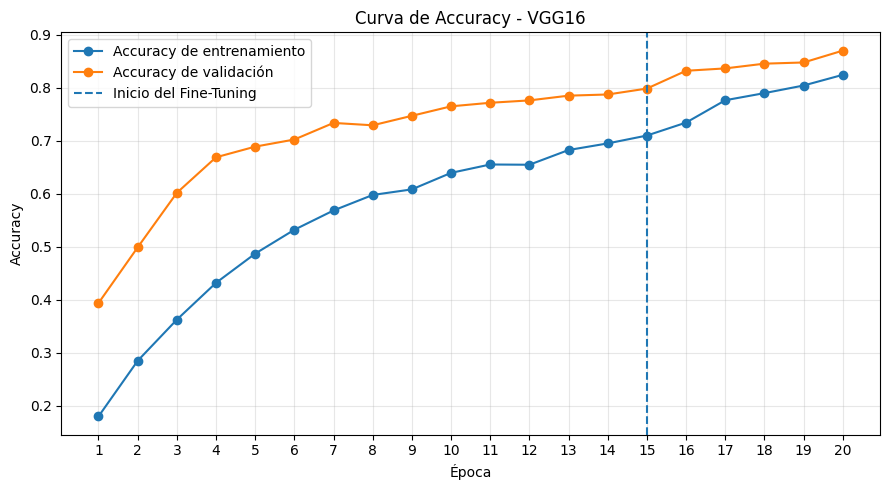

Gráfica guardada: accuracy_vgg16.png


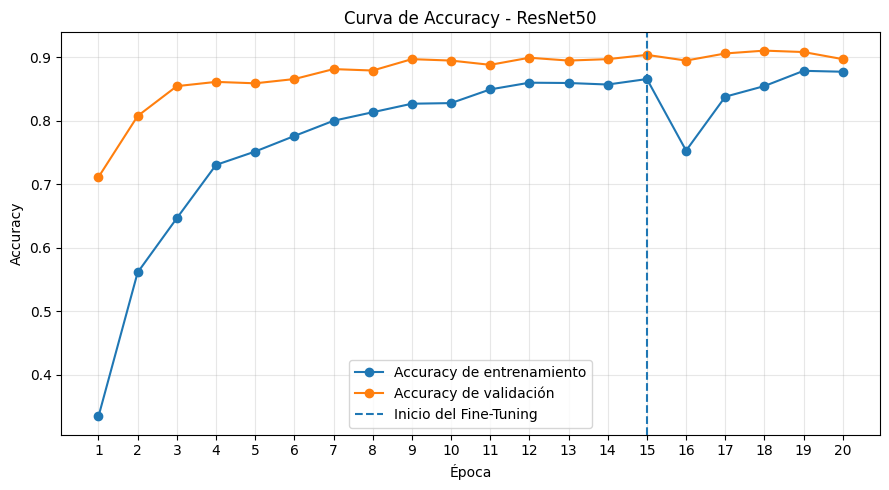

Gráfica guardada: accuracy_resnet50.png


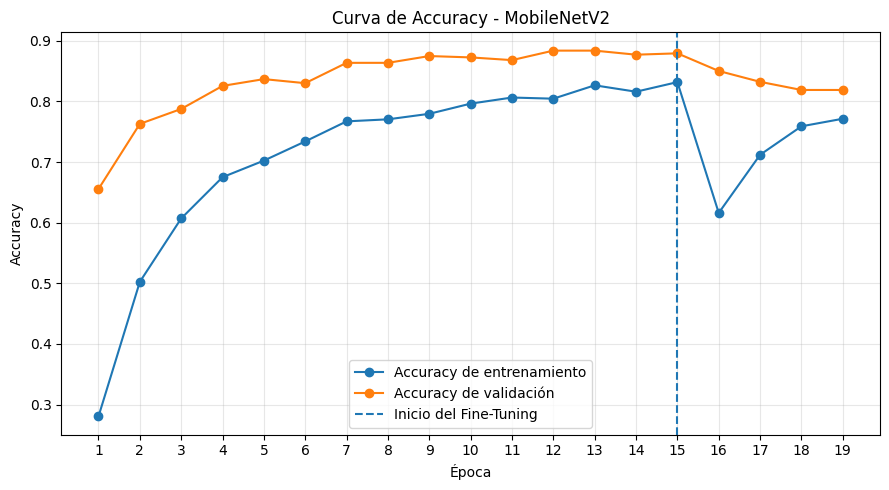

Gráfica guardada: accuracy_mobilenetv2.png


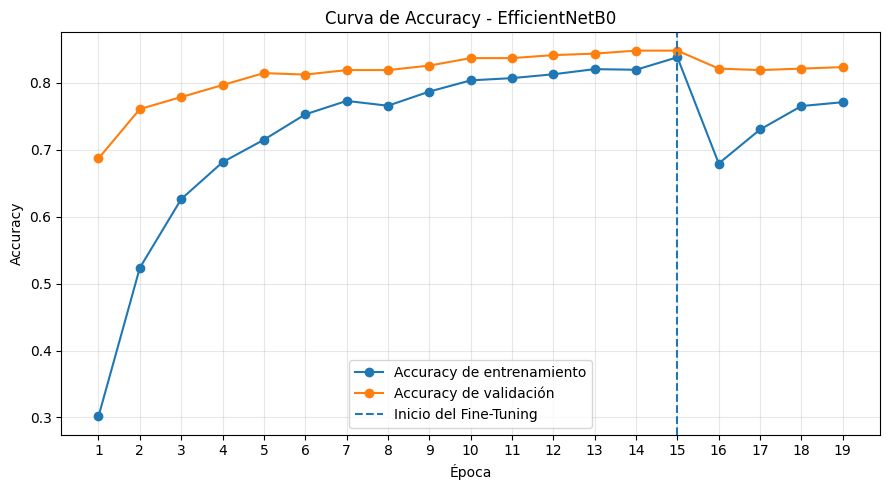

Gráfica guardada: accuracy_efficientnetb0.png


In [44]:
# ==========================================================
# CURVAS DE ACCURACY DE LOS CUATRO MODELOS
# ==========================================================

for nombre, historial in historiales_completos.items():

    epocas = range(1, len(historial["accuracy"]) + 1)

    plt.figure(figsize=(9, 5))

    plt.plot(
        epocas,
        historial["accuracy"],
        marker="o",
        label="Accuracy de entrenamiento"
    )

    plt.plot(
        epocas,
        historial["val_accuracy"],
        marker="o",
        label="Accuracy de validación"
    )

    # Línea que separa Transfer Learning y Fine-Tuning
    plt.axvline(
        x=15,
        linestyle="--",
        label="Inicio del Fine-Tuning"
    )

    plt.title(f"Curva de Accuracy - {nombre}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, len(epocas) + 1))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    nombre_archivo = (
        f"accuracy_{nombre.lower()}.png"
        .replace(" ", "_")
    )

    plt.savefig(
        nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Gráfica guardada: {nombre_archivo}")

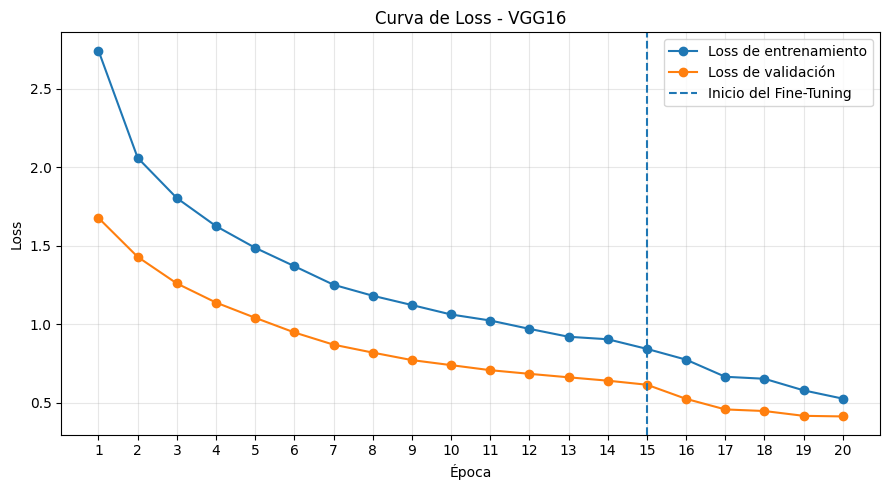

Gráfica guardada: loss_vgg16.png


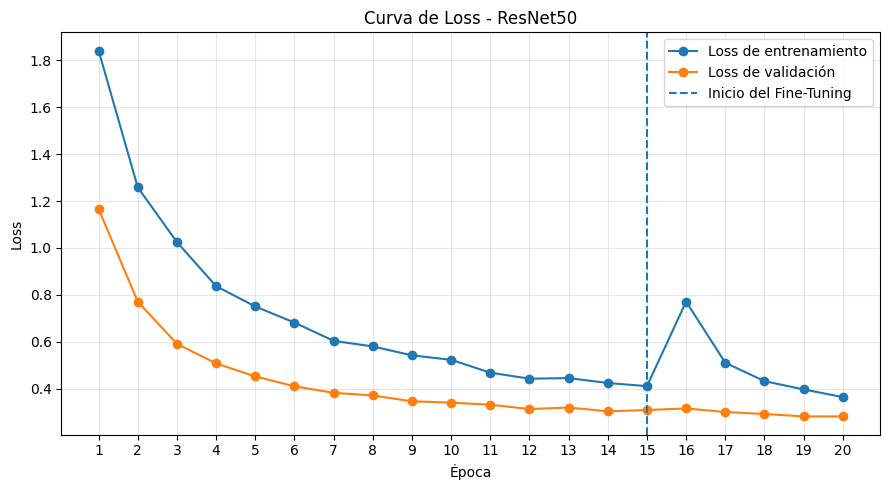

Gráfica guardada: loss_resnet50.png


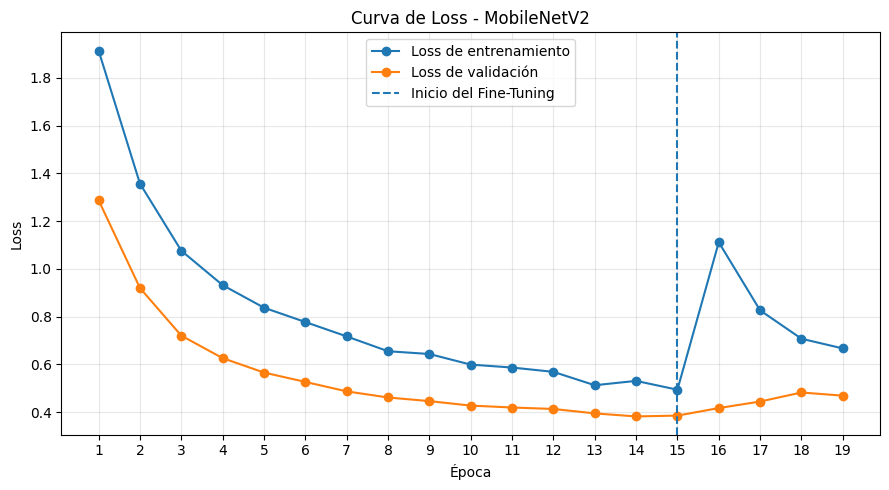

Gráfica guardada: loss_mobilenetv2.png


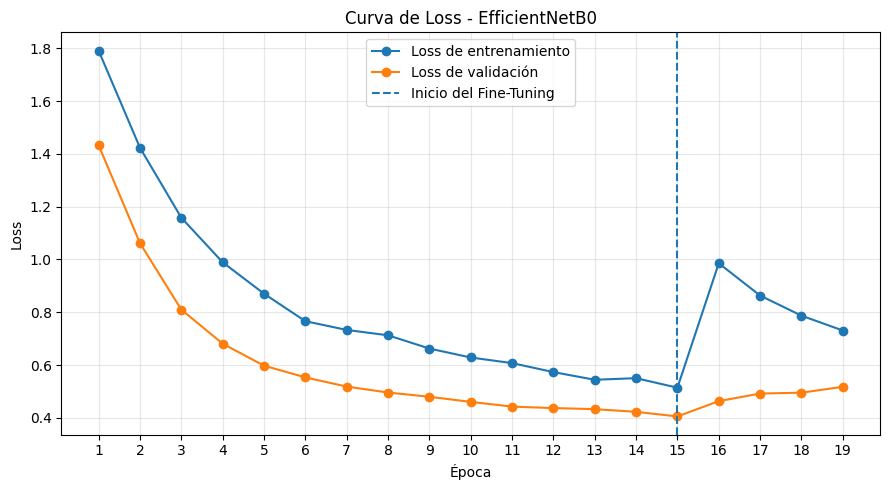

Gráfica guardada: loss_efficientnetb0.png


In [45]:
# ==========================================================
# CURVAS DE LOSS DE LOS CUATRO MODELOS
# ==========================================================

for nombre, historial in historiales_completos.items():

    epocas = range(1, len(historial["loss"]) + 1)

    plt.figure(figsize=(9, 5))

    plt.plot(
        epocas,
        historial["loss"],
        marker="o",
        label="Loss de entrenamiento"
    )

    plt.plot(
        epocas,
        historial["val_loss"],
        marker="o",
        label="Loss de validación"
    )

    plt.axvline(
        x=15,
        linestyle="--",
        label="Inicio del Fine-Tuning"
    )

    plt.title(f"Curva de Loss - {nombre}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(epocas) + 1))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    nombre_archivo = (
        f"loss_{nombre.lower()}.png"
        .replace(" ", "_")
    )

    plt.savefig(
        nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Gráfica guardada: {nombre_archivo}")

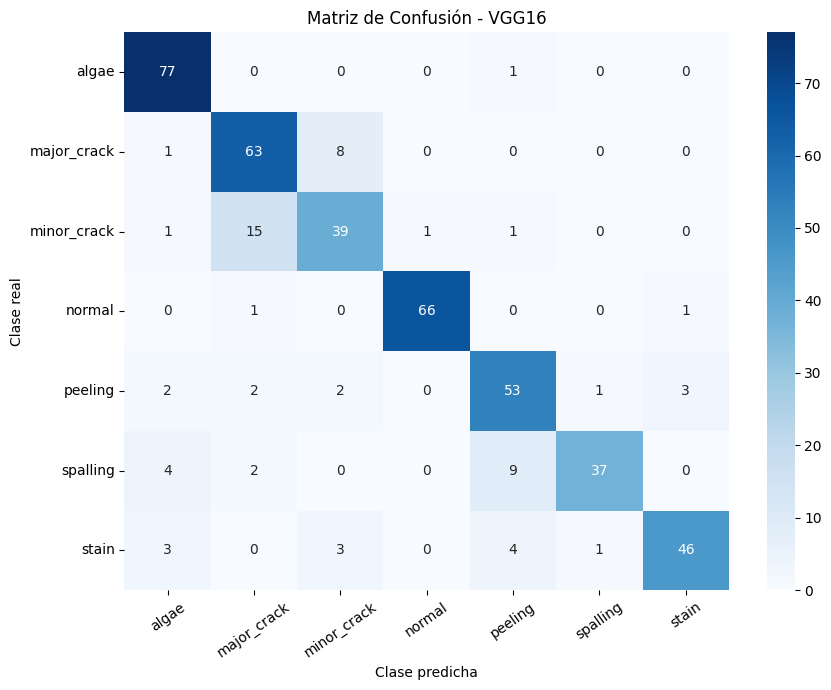

Matriz guardada: matriz_confusion_vgg16.png


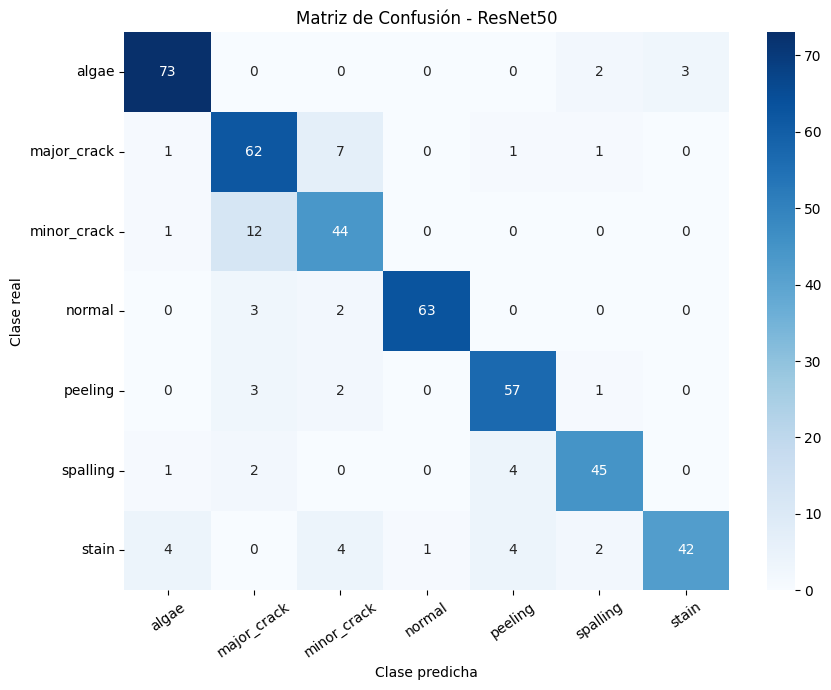

Matriz guardada: matriz_confusion_resnet50.png


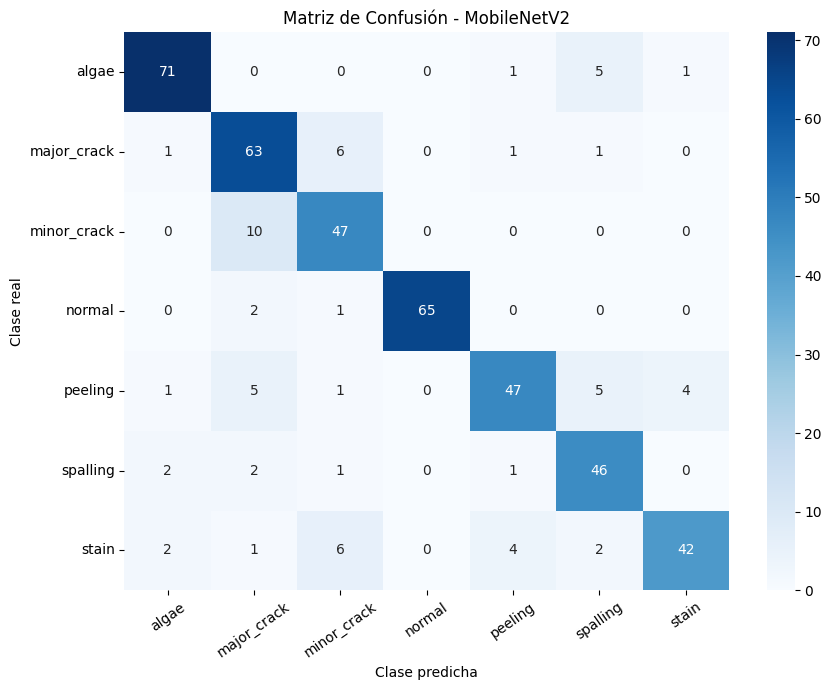

Matriz guardada: matriz_confusion_mobilenetv2.png


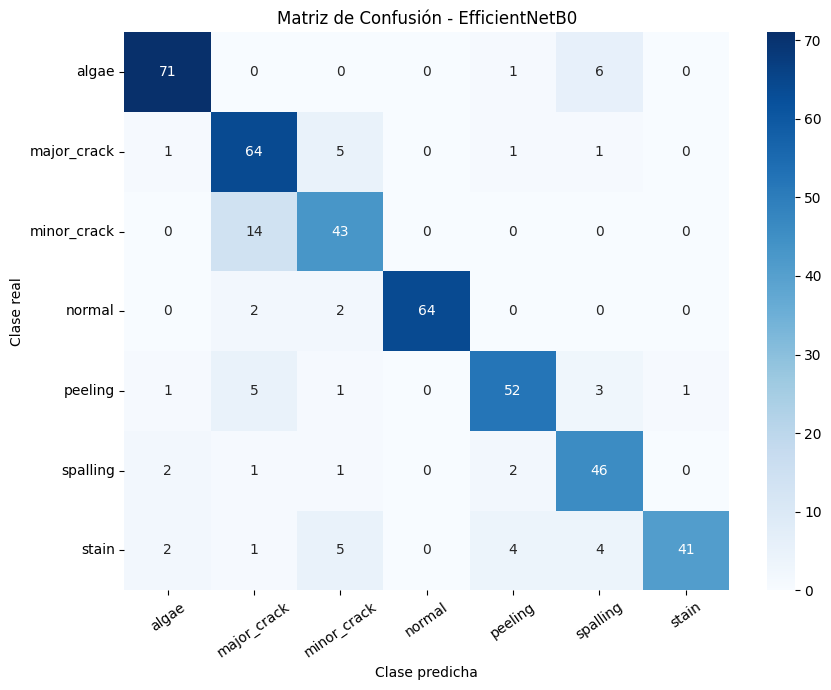

Matriz guardada: matriz_confusion_efficientnetb0.png


In [46]:
# ==========================================================
# MATRICES DE CONFUSIÓN DE LOS CUATRO MODELOS
# ==========================================================

for nombre, resultado in resultados_evaluacion.items():

    matriz = resultado["matriz_confusion"]

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(f"Matriz de Confusión - {nombre}")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.xticks(rotation=35)
    plt.yticks(rotation=0)
    plt.tight_layout()

    nombre_archivo = (
        f"matriz_confusion_{nombre.lower()}.png"
        .replace(" ", "_")
    )

    plt.savefig(
        nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Matriz guardada: {nombre_archivo}")

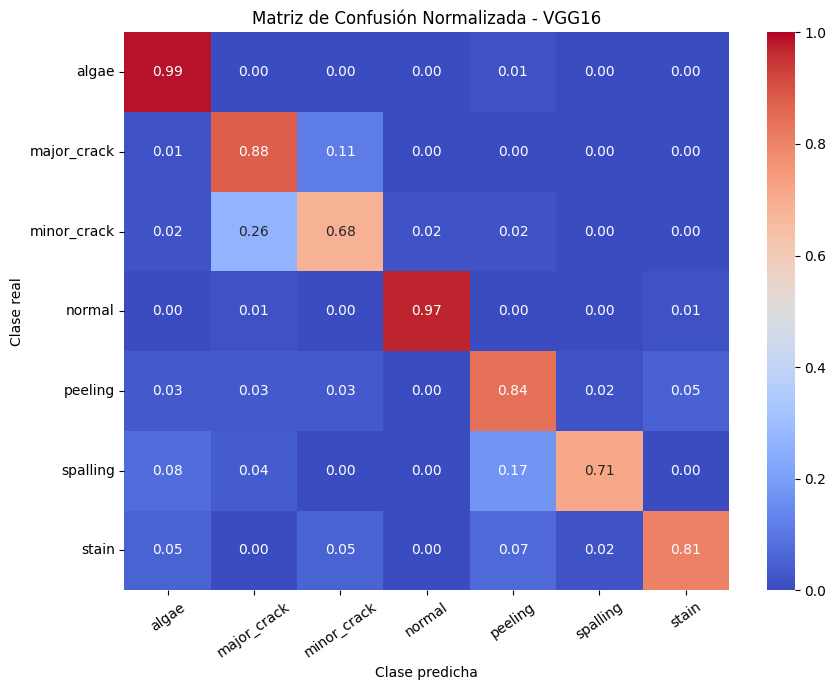

Matriz normalizada guardada: matriz_normalizada_vgg16.png


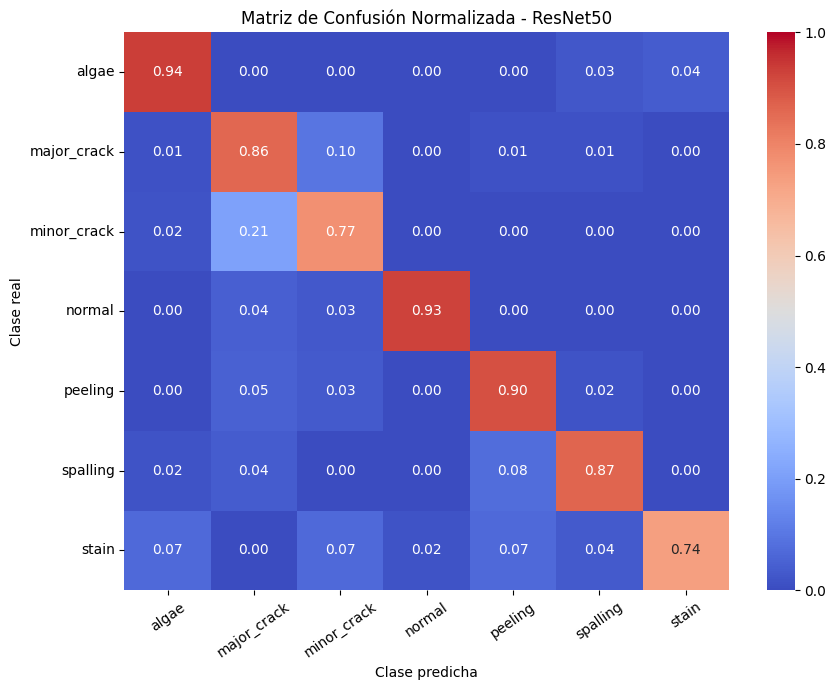

Matriz normalizada guardada: matriz_normalizada_resnet50.png


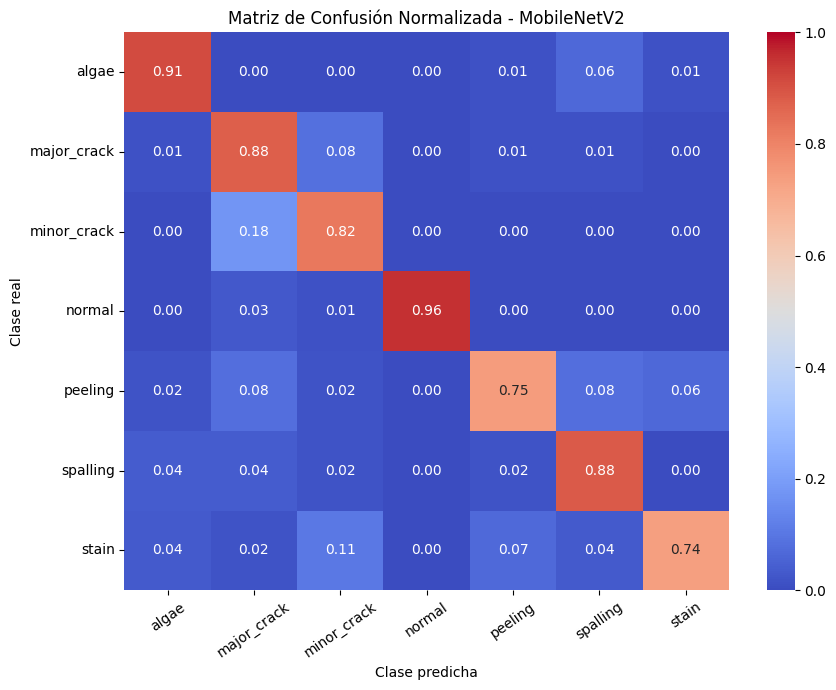

Matriz normalizada guardada: matriz_normalizada_mobilenetv2.png


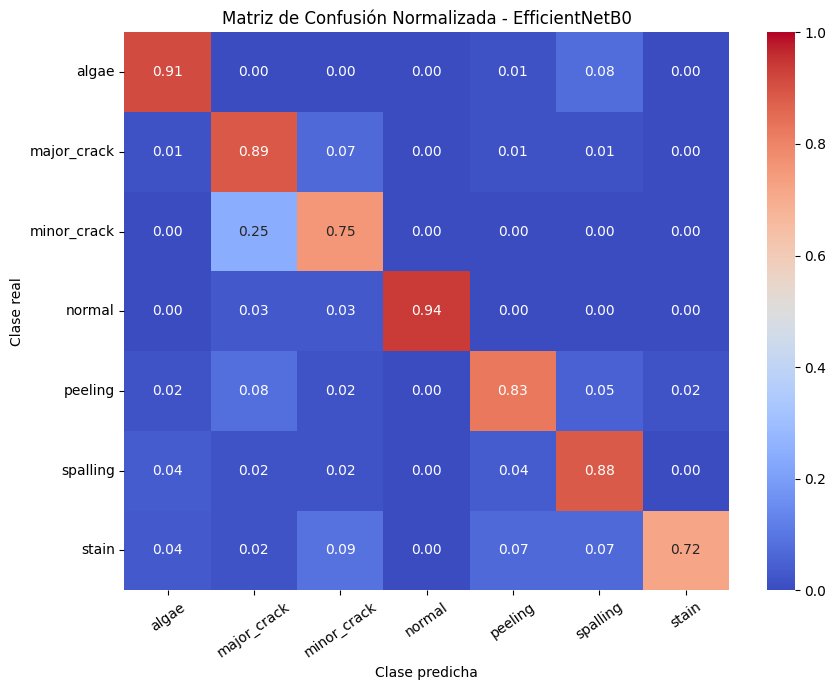

Matriz normalizada guardada: matriz_normalizada_efficientnetb0.png


In [47]:
# ==========================================================
# MATRICES DE CONFUSIÓN NORMALIZADAS
# ==========================================================

for nombre, resultado in resultados_evaluacion.items():

    matriz = resultado["matriz_confusion"].astype("float")

    matriz_normalizada = (
        matriz
        / matriz.sum(axis=1, keepdims=True)
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        matriz_normalizada,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"Matriz de Confusión Normalizada - {nombre}"
    )
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.xticks(rotation=35)
    plt.yticks(rotation=0)
    plt.tight_layout()

    nombre_archivo = (
        f"matriz_normalizada_{nombre.lower()}.png"
        .replace(" ", "_")
    )

    plt.savefig(
        nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Matriz normalizada guardada: {nombre_archivo}")

In [48]:
# ==========================================================
# CLASSIFICATION REPORT DE LAS CUATRO CNN
# ==========================================================

for nombre, resultado in resultados_evaluacion.items():

    print("\n" + "=" * 90)
    print(f"CLASSIFICATION REPORT - {nombre.upper()}")
    print("=" * 90)

    print(resultado["classification_report"])


CLASSIFICATION REPORT - VGG16
              precision    recall  f1-score   support

       algae     0.8750    0.9872    0.9277        78
 major_crack     0.7590    0.8750    0.8129        72
 minor_crack     0.7500    0.6842    0.7156        57
      normal     0.9851    0.9706    0.9778        68
     peeling     0.7794    0.8413    0.8092        63
    spalling     0.9487    0.7115    0.8132        52
       stain     0.9200    0.8070    0.8598        57

    accuracy                         0.8523       447
   macro avg     0.8596    0.8395    0.8452       447
weighted avg     0.8580    0.8523    0.8511       447


CLASSIFICATION REPORT - RESNET50
              precision    recall  f1-score   support

       algae     0.9125    0.9359    0.9241        78
 major_crack     0.7561    0.8611    0.8052        72
 minor_crack     0.7458    0.7719    0.7586        57
      normal     0.9844    0.9265    0.9545        68
     peeling     0.8636    0.9048    0.8837        63
    spalling 

In [49]:
# ==========================================================
# GUARDAR REPORTES EN ARCHIVOS TXT
# ==========================================================

for nombre, resultado in resultados_evaluacion.items():

    nombre_archivo = (
        f"classification_report_{nombre.lower()}.txt"
        .replace(" ", "_")
    )

    with open(
        nombre_archivo,
        "w",
        encoding="utf-8"
    ) as archivo:

        archivo.write(
            f"CLASSIFICATION REPORT - {nombre}\n\n"
        )

        archivo.write(
            resultado["classification_report"]
        )

    print(f"Reporte guardado: {nombre_archivo}")

Reporte guardado: classification_report_vgg16.txt
Reporte guardado: classification_report_resnet50.txt
Reporte guardado: classification_report_mobilenetv2.txt
Reporte guardado: classification_report_efficientnetb0.txt


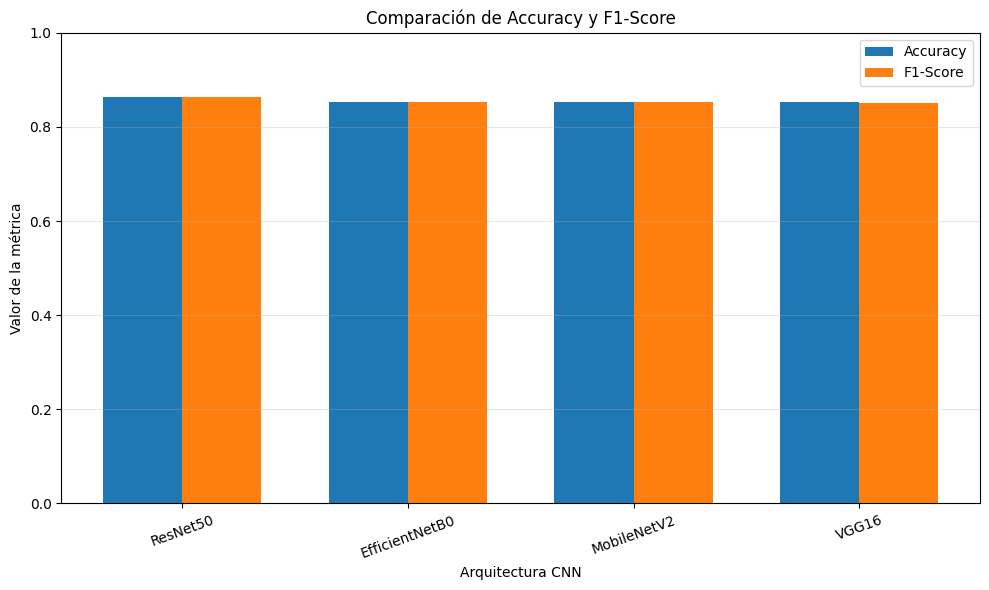

In [50]:
# ==========================================================
# COMPARACIÓN DE ACCURACY Y F1-SCORE
# ==========================================================

tabla_grafica = tabla_comparativa.copy()

x = np.arange(len(tabla_grafica))
ancho = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    tabla_grafica["Accuracy Test"],
    width=ancho,
    label="Accuracy"
)

plt.bar(
    x + ancho / 2,
    tabla_grafica["F1-Score"],
    width=ancho,
    label="F1-Score"
)

plt.xticks(
    x,
    tabla_grafica["Modelo"],
    rotation=20
)

plt.ylim(0, 1)
plt.title("Comparación de Accuracy y F1-Score")
plt.xlabel("Arquitectura CNN")
plt.ylabel("Valor de la métrica")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "comparacion_accuracy_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

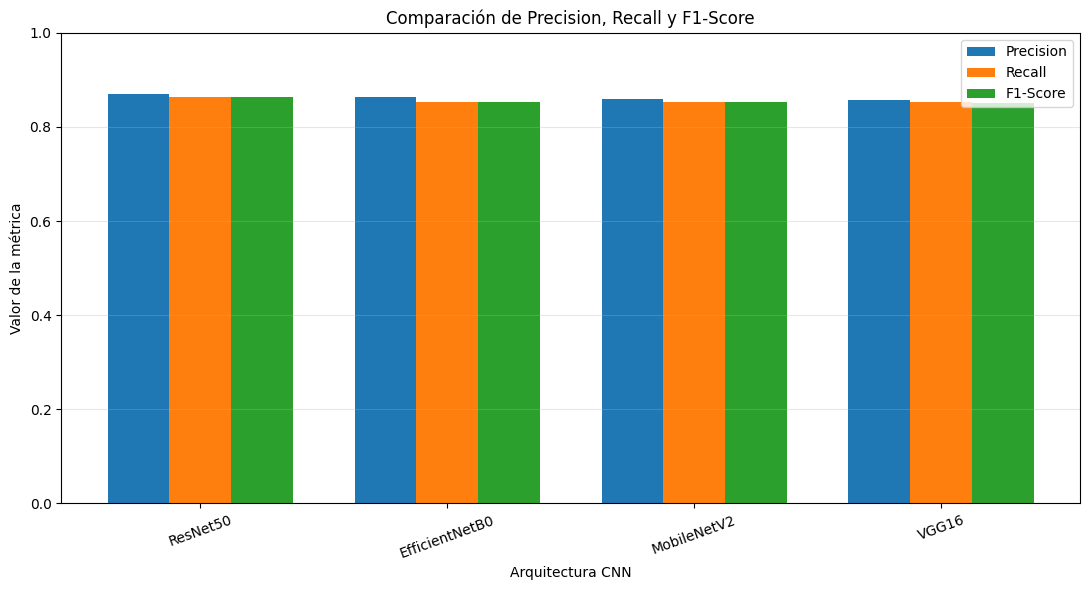

In [51]:
# ==========================================================
# COMPARACIÓN DE PRECISION, RECALL Y F1-SCORE
# ==========================================================

x = np.arange(len(tabla_grafica))
ancho = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - ancho,
    tabla_grafica["Precision"],
    width=ancho,
    label="Precision"
)

plt.bar(
    x,
    tabla_grafica["Recall"],
    width=ancho,
    label="Recall"
)

plt.bar(
    x + ancho,
    tabla_grafica["F1-Score"],
    width=ancho,
    label="F1-Score"
)

plt.xticks(
    x,
    tabla_grafica["Modelo"],
    rotation=20
)

plt.ylim(0, 1)
plt.title("Comparación de Precision, Recall y F1-Score")
plt.xlabel("Arquitectura CNN")
plt.ylabel("Valor de la métrica")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "comparacion_precision_recall_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

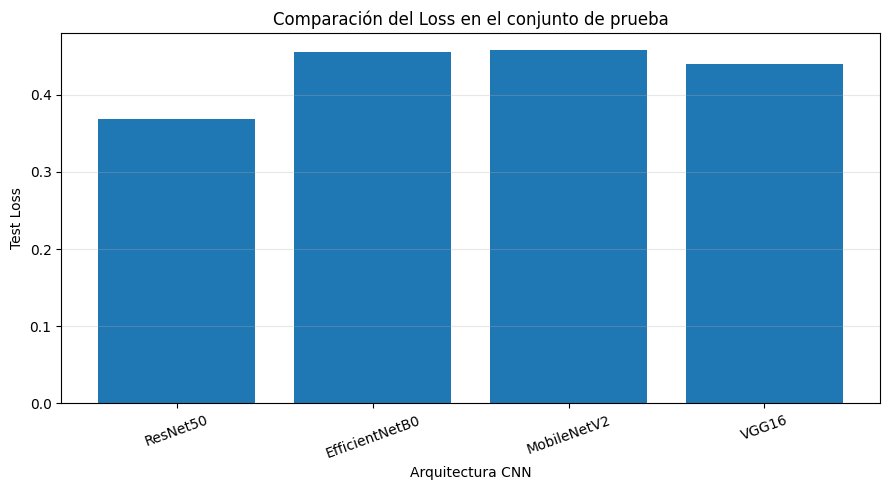

In [52]:
# ==========================================================
# COMPARACIÓN DEL LOSS EN TEST
# ==========================================================

plt.figure(figsize=(9, 5))

plt.bar(
    tabla_grafica["Modelo"],
    tabla_grafica["Loss Test"]
)

plt.title("Comparación del Loss en el conjunto de prueba")
plt.xlabel("Arquitectura CNN")
plt.ylabel("Test Loss")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "comparacion_loss_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

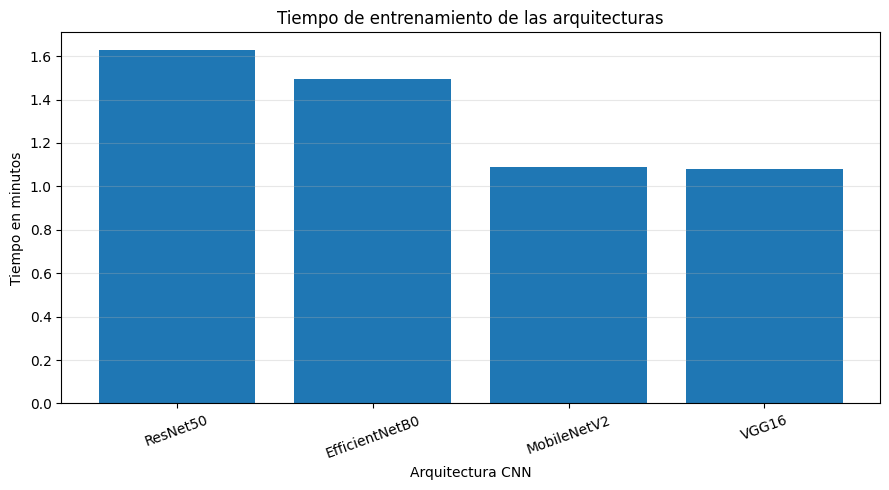

In [53]:
# ==========================================================
# COMPARACIÓN DEL TIEMPO DE ENTRENAMIENTO
# ==========================================================

plt.figure(figsize=(9, 5))

plt.bar(
    tabla_grafica["Modelo"],
    tabla_grafica["Tiempo entrenamiento (min)"]
)

plt.title("Tiempo de entrenamiento de las arquitecturas")
plt.xlabel("Arquitectura CNN")
plt.ylabel("Tiempo en minutos")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "comparacion_tiempo_entrenamiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

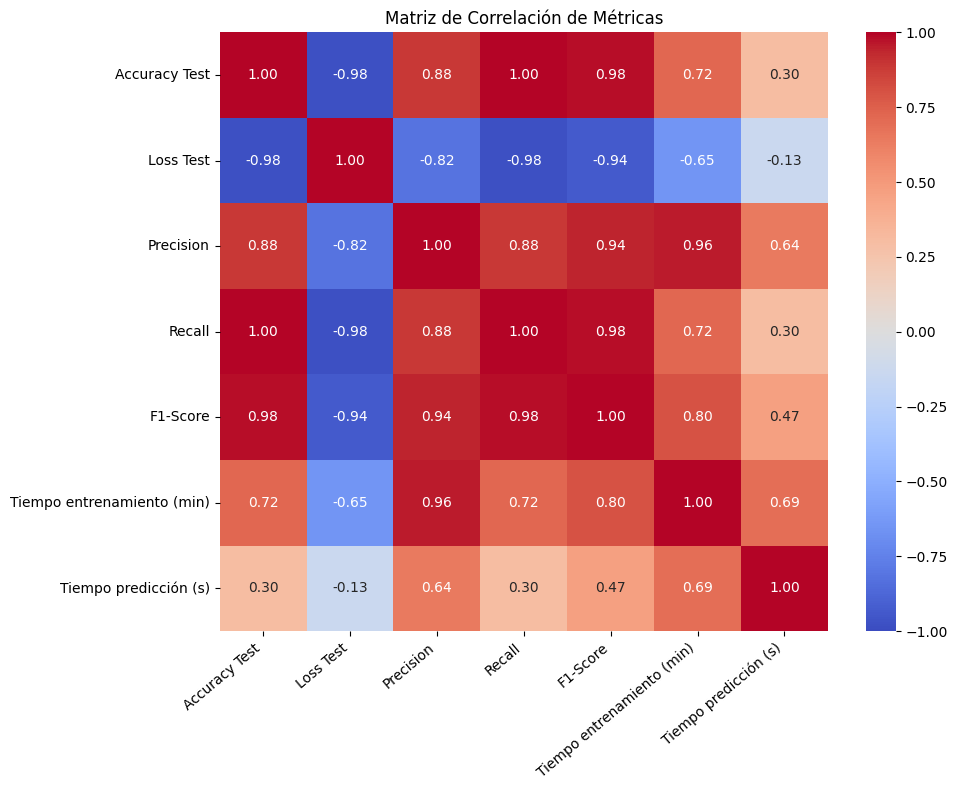

In [54]:
# ==========================================================
# MATRIZ DE CORRELACIÓN DE MÉTRICAS
# ==========================================================

columnas_metricas = [
    "Accuracy Test",
    "Loss Test",
    "Precision",
    "Recall",
    "F1-Score",
    "Tiempo entrenamiento (min)",
    "Tiempo predicción (s)"
]

matriz_correlacion = (
    tabla_comparativa[columnas_metricas]
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Matriz de Correlación de Métricas")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "matriz_correlacion_metricas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# ==========================================================
# CREAR ARCHIVO CON LOS NOMBRES DE LAS 7 CLASES
# ==========================================================

import json

CLASS_NAMES = [
    "algae",
    "major_crack",
    "minor_crack",
    "normal",
    "peeling",
    "spalling",
    "stain"
]

with open("class_names.json", "w", encoding="utf-8") as archivo:
    json.dump(CLASS_NAMES, archivo, ensure_ascii=False, indent=4)

print("Clases guardadas correctamente.")

Clases guardadas correctamente.


In [57]:
# ==========================================================
# EMPAQUETAR LOS CUATRO MODELOS
# ==========================================================

import os
import zipfile

archivos_modelos = [
    "mejor_vgg16_final.keras",
    "mejor_resnet50_final.keras",
    "mejor_mobilenetv2_fase1.keras",
    "mejor_efficientnetb0_fase1.keras",
    "class_names.json"
]

for archivo in archivos_modelos:
    if not os.path.exists(archivo):
        raise FileNotFoundError(f"No se encontró: {archivo}")

nombre_zip = "modelos_4_cnn_defectos.zip"

with zipfile.ZipFile(nombre_zip, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for archivo in archivos_modelos:
        zip_file.write(archivo)

print(f"Paquete creado correctamente: {nombre_zip}")

Paquete creado correctamente: modelos_4_cnn_defectos.zip


In [58]:
from google.colab import files

files.download("modelos_4_cnn_defectos.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>